In [1]:
import numpy as np
import pingouin as pg



In [2]:
np.random.seed(123)
mean, cov, n = [4, 5], [(1, .6), (.6, 1)], 30
x, y = np.random.multivariate_normal(mean, cov, n).T

# T-test
pg.ttest(x, y)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-3.400706,58,two-sided,0.001222,"[-1.68, -0.43]",0.878059,26.155,0.916807


In [4]:
from pingouin import mediation_analysis, read_dataset
df = read_dataset('mediation')
mediation_analysis(data=df, x='X', m='M', y='Y', alpha=0.05,seed=42,n_boot=1000)

,path,coef,se,pval,CI[2.5%],CI[97.5%],sig
0,M ~ X,0.561015,0.094480,4.391362e-08,0.373522,0.748509,Yes
1,Y ~ M,0.654173,0.085831,1.612674e-11,0.483844,0.824501,Yes
2,Total,0.396126,0.111160,5.671128e-04,0.175533,0.616719,Yes
3,Direct,0.039604,0.109648,7.187429e-01,-0.178018,0.257226,No
4,Indirect,0.356522,0.083984,0.000000e+00,0.218835,0.538517,Yes


In [5]:
# add bootstrap samples
df = read_dataset('mediation')
print(len(df))
mediation_analysis(data=df, x='X', m='M', y='Y', alpha=0.05,seed=42,n_boot=5000)

100


,path,coef,se,pval,CI[2.5%],CI[97.5%],sig
0,M ~ X,0.561015,0.094480,4.391362e-08,0.373522,0.748509,Yes
1,Y ~ M,0.654173,0.085831,1.612674e-11,0.483844,0.824501,Yes
2,Total,0.396126,0.111160,5.671128e-04,0.175533,0.616719,Yes
3,Direct,0.039604,0.109648,7.187429e-01,-0.178018,0.257226,No
4,Indirect,0.356522,0.079928,0.000000e+00,0.219475,0.536013,Yes


In [6]:
# add covariates
mediation_analysis(data=df, x='X', m='M', y='Y',
                   covar=['Mbin', 'Ybin'], seed=42).round(3)

,path,coef,se,pval,CI[2.5%],CI[97.5%],sig
0,M ~ X,0.559,0.097,0.000,0.367,0.752,Yes
1,Y ~ M,0.666,0.086,0.000,0.495,0.837,Yes
2,Total,0.420,0.113,0.000,0.196,0.645,Yes
3,Direct,0.064,0.110,0.561,-0.155,0.284,No
4,Indirect,0.356,0.086,0.000,0.209,0.553,Yes


In [7]:
df.describe()

,X,M,Y,Mbin,Ybin,W1,W2
count,100.000000,100.000000,100.000000,100.00,100.000000,100.000000,100.000000
mean,5.990000,4.860000,5.230000,0.45,0.530000,1.435000,0.970000
std,1.743646,1.901727,2.039286,0.50,0.501614,0.872721,0.064354
min,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.800000
25%,5.000000,3.000000,4.000000,0.00,0.000000,0.737500,1.000000
50%,6.000000,5.000000,5.000000,0.00,1.000000,1.400000,1.000000
75%,7.000000,6.000000,7.000000,1.00,1.000000,2.162500,1.000000
max,10.000000,10.000000,10.000000,1.00,1.000000,3.000000,1.000000


In [8]:
from scipy.stats import zscore
df_z = df.apply(zscore)
df_z.describe()

,X,M,Y,Mbin,Ybin,W1,W2
count,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02
mean,-1.521006e-16,-1.759703e-16,-1.940115e-16,-1.776357e-17,2.220446e-18,-5.551115e-17,5.051515e-16
std,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00
min,-3.452636e+00,-2.568446e+00,-2.577543e+00,-9.045340e-01,-1.061913e+00,-1.652567e+00,-2.654954e+00
25%,-5.706360e-01,-9.829856e-01,-6.061909e-01,-9.045340e-01,-1.061913e+00,-8.032511e-01,4.685213e-01
50%,5.764000e-03,7.398817e-02,-1.133528e-01,-9.045340e-01,9.416966e-01,-4.030651e-02,4.685213e-01
75%,5.821640e-01,6.024751e-01,8.723235e-01,1.105542e+00,9.416966e-01,8.377996e-01,4.685213e-01
max,2.311364e+00,2.716423e+00,2.350838e+00,1.105542e+00,9.416966e-01,1.802277e+00,4.685213e-01


In [9]:
mediation_analysis(data=df_z, x='X', m='M', y='Y',
                   covar=['Mbin', 'Ybin'], seed=42).round(3)

,path,coef,se,pval,CI[2.5%],CI[97.5%],sig
0,M ~ X,0.513,0.089,0.000,0.337,0.689,Yes
1,Y ~ M,0.621,0.080,0.000,0.462,0.780,Yes
2,Total,0.359,0.097,0.000,0.168,0.551,Yes
3,Direct,0.055,0.094,0.561,-0.132,0.243,No
4,Indirect,0.304,0.074,0.000,0.179,0.473,Yes


# Setup for voxel-based mediation analysis in stroke 

In [22]:
import nibabel as nb
import pandas as pd
import glob
from pathlib import Path
from matplotlib import pyplot as plt
import time
from pingouin import mediation_analysis
import numpy as np
from scipy.stats import zscore, false_discovery_control


In [3]:
local_extras_dir = '../local_extras/'
#image_path = f'{local_extras_dir}/standardized_disconnectomes/' #pre-standardized
image_path = f'{local_extras_dir}/Structural-Proprioceptive-Disconnectome-Stroke-main/Disconnectomes/'
image_path = f'{local_extras_dir}/STROMAP_MNI_Disconnectomes/'
mask_fname = f'{local_extras_dir}/disconnectome_38sub_WM_mask_no_cerebellum.nii.gz'
bx_df_fname = f'{local_extras_dir}/Demographics_and_Behavioural_Data.csv'



In [4]:
# the disconnectomes uploaded to github are not the same subjects (?) as those used by Mika in the subsequent
# mediation analysis - XXX Why is this?
# 
# # normalized_data_list_ids = ['S01' ,'S03' ,'S04' ,'S05' ,'S07' ,'S08' ,'S09' ,'S10' ,'S11' ,'S12' ,'S13' ,'S14' ,'S16' ,'S17' ,'S18' ,'S19' ,'S20' ,'S21' ,'S22' ,'S23' ,'S24' ,'S25' ,'S26' ,'S27' ,'S28' ,'S29' ,'S30' ,'S31' ,'S32' ,'S33' ,'S34' ,'S35' ,'S36' ,'S37' ,'S38' ,'S39' ,'S41' ,'S42']
# len(normalized_data_list_ids)

In [5]:
all_images = sorted(glob.glob(f'{image_path}/*.nii.gz'))
df = pd.read_csv(bx_df_fname)
mask = nb.load(mask_fname)
mask_d = mask.get_fdata()>0 #convert t binary

print(f'{len(all_images)} images found')
print(f'{(mask.get_fdata()>0).sum()} voxels in mask')
print(f'df shape: {df.shape}')
df.head()

42 images found
672377 voxels in mask
df shape: (39, 6)


,Subject,Sex (M=0),Age (y),FM-UL Score,APM Task Score,VGR Task Score
0,S01,0,79,17.0,3.29,2.82
1,S02,0,50,4.0,5.14,NaN
2,S03,0,68,45.0,1.09,0.94
3,S04,1,49,53.0,2.04,2.48
4,S05,1,50,51.0,2.12,3.52


In [6]:
image_ids = [Path(f).stem.split('-')[1].split('_')[0] for f in all_images]

print(len(image_ids))
df_subset = df[df['Subject'].isin(image_ids)].copy() #select the ones we have images for

df_subset = df_subset.dropna(axis=0) #drop any missing data rows

#now remove any images we do not have data for
good_idx = []
for idx,image_id in enumerate(image_ids):
    if image_id in df_subset['Subject'].to_list():
        good_idx.append(idx)
print(len(good_idx))



42
38


In [7]:
#select the good images
image_ids = [image_ids[i] for i in good_idx]
assert(df_subset.Subject.tolist() == image_ids)
all_images = [all_images[i] for i in good_idx]


In [8]:
for idx,img_f in enumerate(all_images):
    print(idx,end=',')
    img = nb.load(img_f)
    if idx == 0:
        all_data = np.zeros((len(all_images), mask_d.sum()),dtype=np.float32)
    all_data[idx,:] = img.get_fdata()[mask_d]
print("")
print(all_data.shape)

0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,
(38, 672377)


Subjects X voxels
(38, 505011)
[0.30709496 0.32253623 0.30485454 ... 0.01152791 0.01348047 0.01031613]


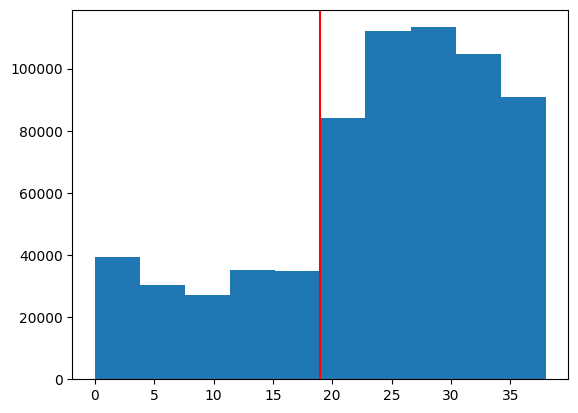

In [13]:
# subselect the data based on some thresholding
#check all_data for locations where there is no disconnectome

vox_pct_thresh = .01 #amount of disconnection to cut at
min_num_Ss= 19 #require this minimum number of subjects
Ss_w_vox_gt_thresh = (all_data>vox_pct_thresh).sum(axis=0)
_ = plt.hist(Ss_w_vox_gt_thresh,bins=10)
plt.axvline(min_num_Ss,color='r')
selected_vox_bool = Ss_w_vox_gt_thresh>=min_num_Ss


d_subset = all_data[:,selected_vox_bool]
d_subset_zscored = (d_subset - d_subset.mean(axis=0)) / d_subset.std(axis=0)

print("Subjects X voxels")
print(d_subset.shape)
print(np.mean(d_subset,axis=0))

out_d = np.zeros(mask_d.shape,dtype=np.int8)
out_d[mask_d] = selected_vox_bool.astype(np.int8)
img_out = nb.Nifti1Image(out_d,mask.affine,mask.header)
img_out.to_filename(f'{local_extras_dir}/selected_voxels_mask_pctThresh_{str(vox_pct_thresh).replace('.','p')}_minSs_{min_num_Ss}.nii.gz')

In [172]:
# %timeit mediation_analysis(data=_df, x='vox_dconn_z', m='APM Task Score', y='VGR Task Score',covar=['Age (y)', 'Sex (M=0)'], seed=42)
# %timeit mediation_analysis(data=_df, x='vox_dconn_z', m='APM Task Score', y='VGR Task Score',covar=['Age (y)', 'Sex (M=0)'], seed=42, n_boot=5000)

In [16]:
#setup the data structures for running the analysis
M_var = 'APM Task Score' #set the mediator
Y_var = 'VGR Task Score' #set the outcome variable
# Y_var = 'FM-UL Score'
vox_idx = 0
_df = df_subset.copy()
_df['vox_dconn_z'] = d_subset_zscored[:,vox_idx]

# zscore the numeric columns
_df = _df.apply(lambda x: zscore(x) if x.name not in ['Subject'] else x)

res = mediation_analysis(data=_df, x='vox_dconn_z', m=M_var, y=Y_var,
                covar=['Age (y)', 'Sex (M=0)'], seed=42)

#column and rownames, so that we know what the outputs were
column_names = res.columns
row_names = res[column_names[0]].to_list()

n_vox = d_subset_zscored.shape[1]
print(_df.describe())
_df.head()

          Sex (M=0)       Age (y)  ...  VGR Task Score   vox_dconn_z
count  3.800000e+01  3.800000e+01  ...    3.800000e+01  3.800000e+01
mean   2.337312e-17  1.110223e-16  ...    1.754810e-16  3.137087e-09
std    1.013423e+00  1.013423e+00  ...    1.013423e+00  1.013423e+00
min   -7.211103e-01 -2.348124e+00  ...   -1.646063e+00 -8.260882e-01
25%   -7.211103e-01 -5.551671e-01  ...   -9.080877e-01 -8.260882e-01
50%   -7.211103e-01 -1.593195e-01  ...    1.194723e-01 -3.779772e-01
75%    1.386750e+00  7.255163e-01  ...    7.546912e-01  5.200523e-01
max    1.386750e+00  1.936344e+00  ...    2.015788e+00  1.863921e+00

[8 rows x 6 columns]


,Subject,Sex (M=0),Age (y),FM-UL Score,APM Task Score,VGR Task Score,vox_dconn_z
0,S01,-0.72111,1.750063,-2.492071,1.301527,0.110131,1.415573
2,S03,-0.72111,0.725516,-0.219951,-0.543609,-1.646063,-0.826088
3,S04,1.38675,-1.044155,0.429226,0.253154,-0.207479,0.071623
4,S05,1.38675,-0.951015,0.266931,0.320250,0.764033,-0.826088
5,S07,-0.72111,-0.392171,0.185784,-0.543609,0.595886,-0.826088


In [17]:
res

,path,coef,se,pval,CI[2.5%],CI[97.5%],sig
0,APM Task Score ~ X,0.454234,0.143975,0.003351,0.161641,0.746828,Yes
1,Y ~ APM Task Score,0.496471,0.161193,0.004081,0.168888,0.824054,Yes
2,Total,0.204057,0.170452,0.239528,-0.142344,0.550457,No
3,Direct,-0.027739,0.177505,0.876770,-0.388876,0.333398,No
4,Indirect,0.231796,0.159117,0.004000,0.040248,0.669829,Yes


In [18]:
import numpy as np
from joblib import Parallel, delayed

def run_single_voxel(vox_idx,M_var,Y_var,n_boot=10): #set n_boot to 50 for speed (5000 for real)
    X = d_subset_zscored[:, vox_idx]

    # Construct minimal DataFrame for each voxel/worker
    _t_df = _df.copy()
    _t_df['vox_dconn_z'] = X

    res = mediation_analysis(
        data=_t_df,
        x='vox_dconn_z',
        m=M_var,
        y=Y_var,
        covar=['Age (y)', 'Sex (M=0)'],
        seed=42,
        n_boot=n_boot,
    ).to_numpy()

    # Output buffers (float32 faster & safer than float16)
    M_X = np.zeros(6, dtype=np.float32)
    Y_M = np.zeros(6, dtype=np.float32)
    tot = np.zeros(6, dtype=np.float32)
    direct = np.zeros(6, dtype=np.float32)
    indirect = np.zeros(6, dtype=np.float32)

    for name, *vals in res:
        vals[-1] = 1.0 if vals[-1] == 'Yes' else 0.0

        if name == f'{M_var} ~ X':
            M_X[:] = vals
        elif name == f'Y ~ {M_var}':
            Y_M[:] = vals
        elif name == 'Total':
            tot[:] = vals
        elif name == 'Direct':
            direct[:] = vals
        elif name == 'Indirect':
            indirect[:] = vals

    return M_X, Y_M, tot, direct, indirect


In [19]:
#test to see that it works the way that you expected
n_boot = 500
results = Parallel(
    n_jobs=-1,          # use all cores
    backend='loky',
    verbose=5
)(
    delayed(run_single_voxel)(i,M_var,Y_var,n_boot=n_boot) for i in range(10)
)

_M_X = np.vstack([r[0] for r in results])
_Y_M = np.vstack([r[1] for r in results])
_tot = np.vstack([r[2] for r in results])
_direct = np.vstack([r[3] for r in results])
_indirect = np.vstack([r[4] for r in results])
print(column_names[1:])
_indirect


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of  10 | elapsed:    2.1s remaining:    5.0s
[Parallel(n_jobs=-1)]: Done   6 out of  10 | elapsed:    2.6s remaining:    1.8s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    2.8s finished


Index(['coef', 'se', 'pval', 'CI[2.5%]', 'CI[97.5%]', 'sig'], dtype='object')


array([[0.23179615, 0.15911728, 0.004     , 0.04024803, 0.66982895,
        1.        ],
       [0.23232795, 0.15263763, 0.016     , 0.03568187, 0.6124961 ,
        1.        ],
       [0.22541216, 0.15401165, 0.012     , 0.03254546, 0.600498  ,
        1.        ],
       [0.22531912, 0.13982399, 0.012     , 0.03828191, 0.5555929 ,
        1.        ],
       [0.23523049, 0.14252703, 0.016     , 0.04290339, 0.57889193,
        1.        ],
       [0.21038434, 0.12115474, 0.016     , 0.04870543, 0.5846915 ,
        1.        ],
       [0.22822295, 0.14592458, 0.012     , 0.04008876, 0.580873  ,
        1.        ],
       [0.23454012, 0.14277826, 0.016     , 0.03946879, 0.5844754 ,
        1.        ],
       [0.20708834, 0.13540488, 0.012     , 0.03489234, 0.5272713 ,
        1.        ],
       [0.22871079, 0.13990006, 0.016     , 0.03492021, 0.540335  ,
        1.        ]], dtype=float32)

In [47]:
n_boot = 5
print(f'd_subset_zscored.shape = {d_subset_zscored.shape}')
results = Parallel(
    n_jobs=10,          # use all cores
    backend='loky',
    verbose=5
)(
    delayed(run_single_voxel)(i,M_var,Y_var,n_boot=n_boot) for i in range(n_vox)
)

M_X = np.vstack([r[0] for r in results])
Y_M = np.vstack([r[1] for r in results])
tot = np.vstack([r[2] for r in results])
direct = np.vstack([r[3] for r in results])
indirect = np.vstack([r[4] for r in results])



d_subset_zscored.shape = (38, 505011)


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  52 tasks      | elapsed:    4.4s
[Parallel(n_jobs=10)]: Done 348 tasks      | elapsed:    5.9s
[Parallel(n_jobs=10)]: Done 852 tasks      | elapsed:    7.9s
[Parallel(n_jobs=10)]: Done 1500 tasks      | elapsed:   10.2s
[Parallel(n_jobs=10)]: Done 2292 tasks      | elapsed:   13.0s
[Parallel(n_jobs=10)]: Done 3228 tasks      | elapsed:   16.4s
[Parallel(n_jobs=10)]: Done 4308 tasks      | elapsed:   20.4s
[Parallel(n_jobs=10)]: Done 5532 tasks      | elapsed:   24.7s
[Parallel(n_jobs=10)]: Done 6900 tasks      | elapsed:   29.6s
[Parallel(n_jobs=10)]: Done 8412 tasks      | elapsed:   35.0s
[Parallel(n_jobs=10)]: Done 10068 tasks      | elapsed:   42.8s
[Parallel(n_jobs=10)]: Done 11868 tasks      | elapsed:   50.2s
[Parallel(n_jobs=10)]: Done 13812 tasks      | elapsed:  1.0min
[Parallel(n_jobs=10)]: Done 15900 tasks      | elapsed:  1.2min
[Parallel(n_jobs=10)]: Done 18132 tasks 

In [48]:

#have to do this in 2 steps to get back into full image space

for col_txt in column_names[1:]:
    col_idx = np.where(column_names[1:]==col_txt)[0][0]
    
    col_txt = col_txt.replace(' ','_').replace('.','p').replace('%','pct')

    mediator_txt = M_var.replace(' ','_')
    outcome_txt = Y_var.replace(' ','_')
    fname_head = f'mediation_{outcome_txt}_by_{mediator_txt}_pctThresh_{str(vox_pct_thresh).replace('.','p')}_minSs_{min_num_Ss}'
    
    #X_M
    d_vec = np.zeros((mask_d>0).sum(),dtype=np.float32)
    d_vec[selected_vox_bool] = M_X[:,col_idx]

    d_out = np.zeros_like(mask_d,dtype=np.float32)
    d_out[mask_d] = d_vec
    img_out = nb.Nifti1Image(d_out,affine=img.affine,header=img.header)
    img_out.to_filename(f'{local_extras_dir}/{fname_head}_M_X_zscored_nboot_{n_boot}_{col_txt}.nii.gz')

    #Y_M
    d_vec = np.zeros((mask_d>0).sum(),dtype=np.float32)
    d_vec[selected_vox_bool] = Y_M[:,col_idx]

    d_out = np.zeros_like(mask_d,dtype=np.float32)
    d_out[mask_d] = d_vec
    img_out = nb.Nifti1Image(d_out,affine=img.affine,header=img.header)
    img_out.to_filename(f'{local_extras_dir}/{fname_head}_Y_M_zscored_nboot_{n_boot}_{col_txt}.nii.gz')

    #total
    d_vec = np.zeros((mask_d>0).sum(),dtype=np.float32)
    d_vec[selected_vox_bool] = tot[:,col_idx]

    d_out = np.zeros_like(mask_d,dtype=np.float32)
    d_out[mask_d] = d_vec
    img_out = nb.Nifti1Image(d_out,affine=img.affine,header=img.header)
    img_out.to_filename(f'{local_extras_dir}/{fname_head}_total_zscored_nboot_{n_boot}_{col_txt}.nii.gz')

    #direct
    d_vec = np.zeros((mask_d>0).sum(),dtype=np.float32)
    d_vec[selected_vox_bool] = direct[:,col_idx]

    d_out = np.zeros_like(mask_d,dtype=np.float32)
    d_out[mask_d] = d_vec
    img_out = nb.Nifti1Image(d_out,affine=img.affine,header=img.header)
    img_out.to_filename(f'{local_extras_dir}/{fname_head}_direct_zscored_nboot_{n_boot}_{col_txt}.nii.gz')

    #indirect
    d_vec = np.zeros((mask_d>0).sum(),dtype=np.float32)
    d_vec[selected_vox_bool] = indirect[:,col_idx]

    d_out = np.zeros_like(mask_d,dtype=np.float32)
    d_out[mask_d] = d_vec
    img_out = nb.Nifti1Image(d_out,affine=img.affine,header=img.header)
    img_out.to_filename(f'{local_extras_dir}/{fname_head}_indirect_zscored_nboot_{n_boot}_{col_txt}.nii.gz')


    #indirect minus direct
    if col_txt == "coef":
        d_vec = np.zeros((mask_d>0).sum(),dtype=np.float32)
        d_vec[selected_vox_bool] = np.abs(indirect[:,col_idx]) - np.abs(direct[:,0])

        d_out = np.zeros_like(mask_d,dtype=np.float32)
        d_out[mask_d] = d_vec
        img_out = nb.Nifti1Image(d_out,affine=img.affine,header=img.header)
        img_out.to_filename(f'{local_extras_dir}/{fname_head}_indirect_minus_direct_zscored_nboot_{n_boot}_{col_txt}.nii.gz')


([<matplotlib.lines.Line2D at 0x75502c6bacc0>], (0.0, 0.05))

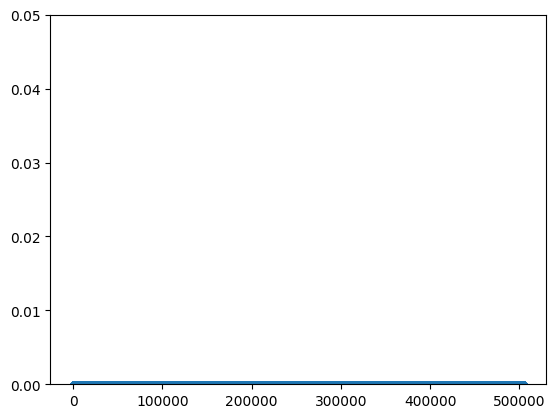

In [43]:
# _=plt.hist(direct[:,2],bins=100)
plt.plot(indirect[:,2],'.'),plt.ylim(0,.05)

0


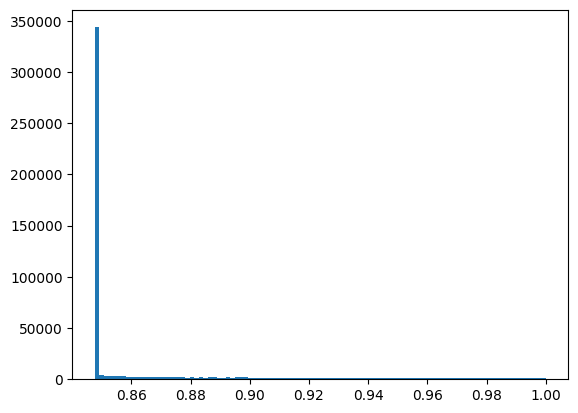

In [ ]:
_ = plt.hist((direct[:,2]),bins=100)
print((false_discovery_control(direct[:,2])<0.5).sum())

In [307]:
mask_d

array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, Fal

In [ ]:
%timeit mediation_analysis(data=_df, x='vox_dconn_z', m='APM Task Score', y='VGR Task Score',covar=['Age (y)', 'Sex (M=0)'], seed=42).to_numpy()

112 ms ± 6.22 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [293]:
%timeit run_single_voxel(0,n_boot=10)

11.3 ms ± 101 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
st = time.time()
_r = run_single_voxel(0,n_boot=5)
print(time.time()-st)
st = time.time()
_r2 = run_single_voxel(0,n_boot=5000)
print(time.time()-st)



0.017385005950927734
1.1070659160614014


(array([0.45423442, 0.14397542, 0.00335115, 0.16164117, 0.7468277 ,
        1.        ], dtype=float32),
 array([0.49647132, 0.16119266, 0.00408123, 0.16888842, 0.8240542 ,
        1.        ], dtype=float32),
 array([ 0.20405684,  0.17045216,  0.23952845, -0.14234364,  0.55045736,
         0.        ], dtype=float32),
 array([-0.02773931,  0.17750524,  0.8767698 , -0.38887644,  0.3333978 ,
         0.        ], dtype=float32),
 array([0.23179616, 0.19184901, 0.        , 0.26243585, 0.26243585,
        1.        ], dtype=float32))

In [ ]:
res2 = run_single_voxel(0)
vox_idx = 0
_df['vox_dconn_z'] = all_data[:,vox_idx]
res = mediation_analysis(data=_df, x='vox_dconn_z', m='APM Task Score', y='VGR Task Score',covar=['Age (y)', 'Sex (M=0)'], seed=42).to_numpy()


In [ ]:
for idx,rr in enumerate(res):
    print(f'{rr[2]} {res2[idx][1]}')


0.17166532520794564 0.17166532576084137
0.1447226506999749 0.14472265541553497
0.1824685483196152 0.18246854841709137
0.19001883767958302 0.19001883268356323
0.17033459063854972 0.170334592461586
